In [42]:
import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

from flonacomldft.utils.diagnostics import avg_windows
from matplotlib.pyplot import cm

In [43]:
def load_simulation_info(id, i, isomer, add_part_ratios=False, path=os.getcwd()):
    id_name = "{:d}{:d}".format(id, i)
    
    file_accs = path + "results_adaptive_is{:d}_{:s}/accs_is{:d}_{:s}.csv".format(isomer, id_name, isomer, id_name)
    df_acc = pd.read_csv(file_accs)
    accs = df_acc[["accs", "time"]].to_numpy()
    
    if add_part_ratios:
        file_part_ratios = path + "results_adaptive_is{:d}_{:s}/part_ratios_is{:d}_{:s}.csv".format(isomer, id_name, isomer, id_name)
        df_part_ratios = pd.read_csv(file_part_ratios)
        part_ratios = df_part_ratios[["part_ratios", "time"]].to_numpy()

    file_args = path + "results_adaptive_is{:d}_{:s}/args_adaptive_sampling_{:s}.json".format(isomer,id_name, id_name)
    f = open(file_args)
    args = json.load(f)
    f.close()
    
    if add_part_ratios:
        return accs, args, part_ratios
    else:
        return accs, args

In [44]:
def get_information(ids, path, n_sim, isomer, add_part_ratios=False):
    
    if add_part_ratios:
        all_part_ratios = []
    
    all_accs = []
    all_args = []

    for id_ in ids:
        for j in range(0, n_sim):
            data = load_simulation_info(id_, j, isomer=isomer, path=path, add_part_ratios=add_part_ratios)
            all_accs.append(data[0])
            all_args.append(data[1])
            
            if add_part_ratios:
                all_part_ratios.append(data[2])

    md = np.unique([args["folder_path"] for args in all_args])

    hyperparams = ['learning_rate', 'n_iter', 'batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'n_runs', 'n_chains', 'n_steps']
    hyperparams_values = [[] for i in range(len(hyperparams))]

    for i in range(len(hyperparams)):
        for args in all_args:
            hyperparams_values[i].append(args[hyperparams[i]])
            
    hyperparams_values = [np.unique(hyperparams_values[i]) for i in range(len(hyperparams))]
    
    to_return = {'all_accs': all_accs,
                 'all_args': all_args,
                 'hyperparams': hyperparams,
                 'hyperparams_values': hyperparams_values,
                 'isomer': isomer,
                 'md': md,
                }
    
    if add_part_ratios:
        to_return['all_part_ratios'] = all_part_ratios

    
    return to_return

In [45]:
def plot_hyperparams_search_with_ratios(simulation_data, key, ylabel, window=100, upper_bound=0.0):
    
    isomer = simulation_data['isomer']
    md = simulation_data['md']
    all_values = simulation_data[key]
    all_args = simulation_data['all_args']
    hyperparams = simulation_data['hyperparams']
    hyperparams_values = simulation_data['hyperparams_values']
    
    fig, axs = plt.subplots(3, 3, figsize=(20, 16))
    fig.subplots_adjust(top=0.92)

    axs = axs.ravel()

    for i in range(len(all_values)):
    
        x = all_values[i][:, 1]/3600
        y = all_values[i][:, 0]

        x_avg = avg_windows(x, window, axis=1)
        y_avg = avg_windows(y, window, axis=1)

        if y_avg.max() > upper_bound:

            for j in range(len(hyperparams)):
                c = cm.jet(np.linspace(0.1, 0.9, len(hyperparams_values[j])))
                mask = hyperparams_values[j] == all_args[i][hyperparams[j]]
                axs[j].plot(x_avg, y_avg, c=c[mask][0], alpha=0.6, label=hyperparams[j]+"="+str(all_args[i][hyperparams[j]]))

                axs[j].set_title(hyperparams[j])
                axs[j].set_xlabel("Time (h)")
                axs[j].set_ylabel(ylabel)

                handles, labels = axs[j].get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                axs[j].legend(by_label.values(), by_label.keys())

    fig.suptitle("Adaptive MCMC params: \n isomer={} md={}".format(isomer,
                                                                md[0],) )
    
    return fig, axs

## EMT grid search with acceptance and participation ratio

In [46]:
ids = [2506662, 2507388, 2512683]
n_sim = 32
isomer = 1
path = "/mnt/home/amolina/ceph/EMT/3-adaptive/results_5/"

emt_grid_search = get_information(ids, path, n_sim, isomer, add_part_ratios=True)

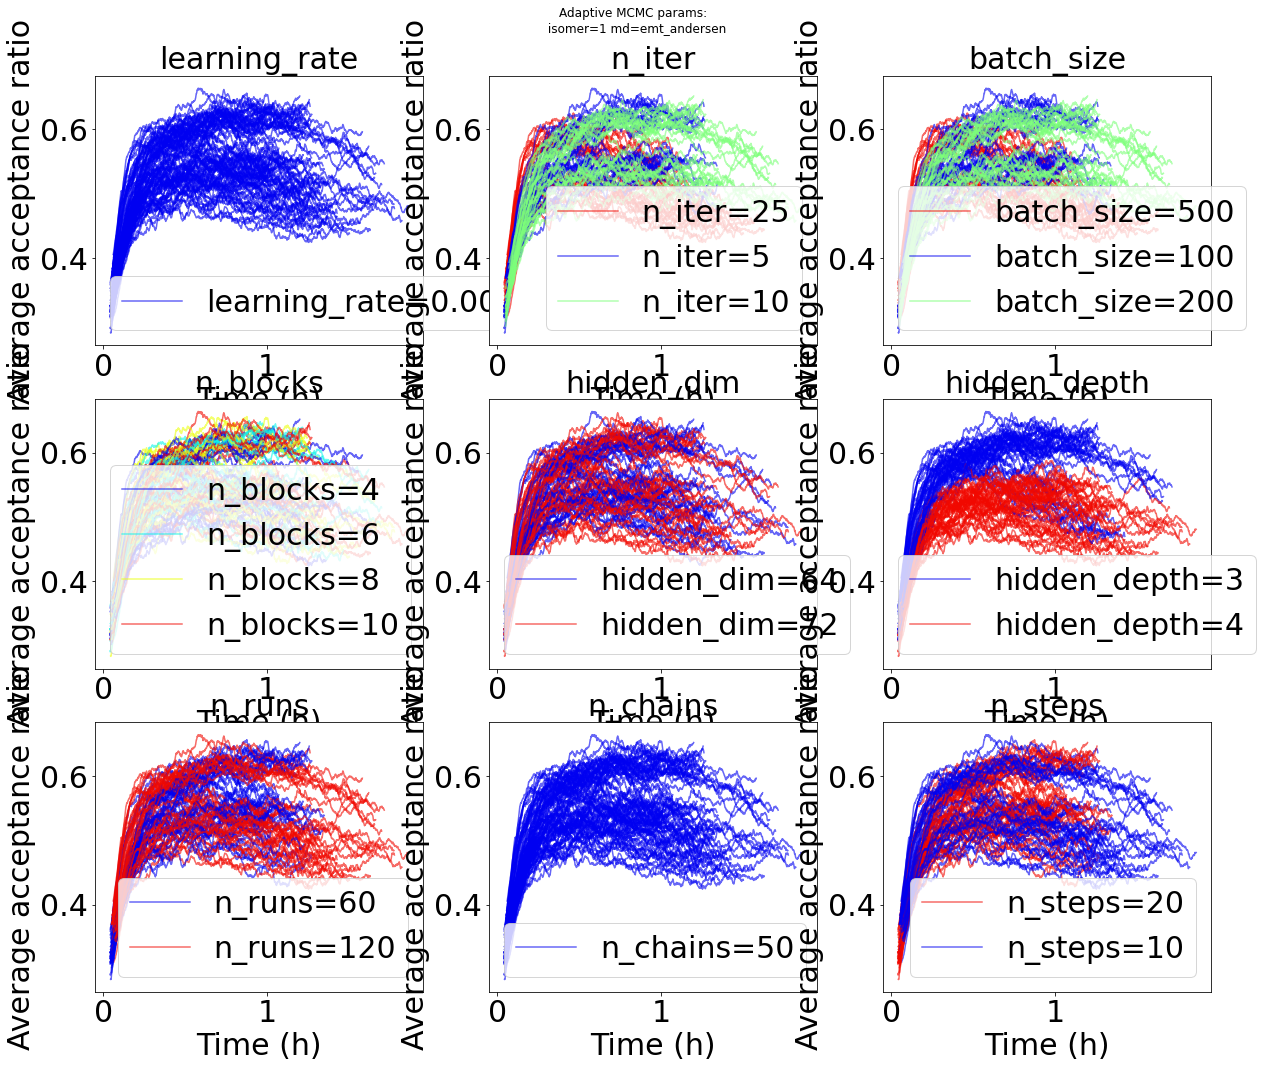

In [47]:
plot_hyperparams_search_with_ratios(emt_grid_search, "all_accs", "Average acceptance ratio", window=100, upper_bound=0.0);

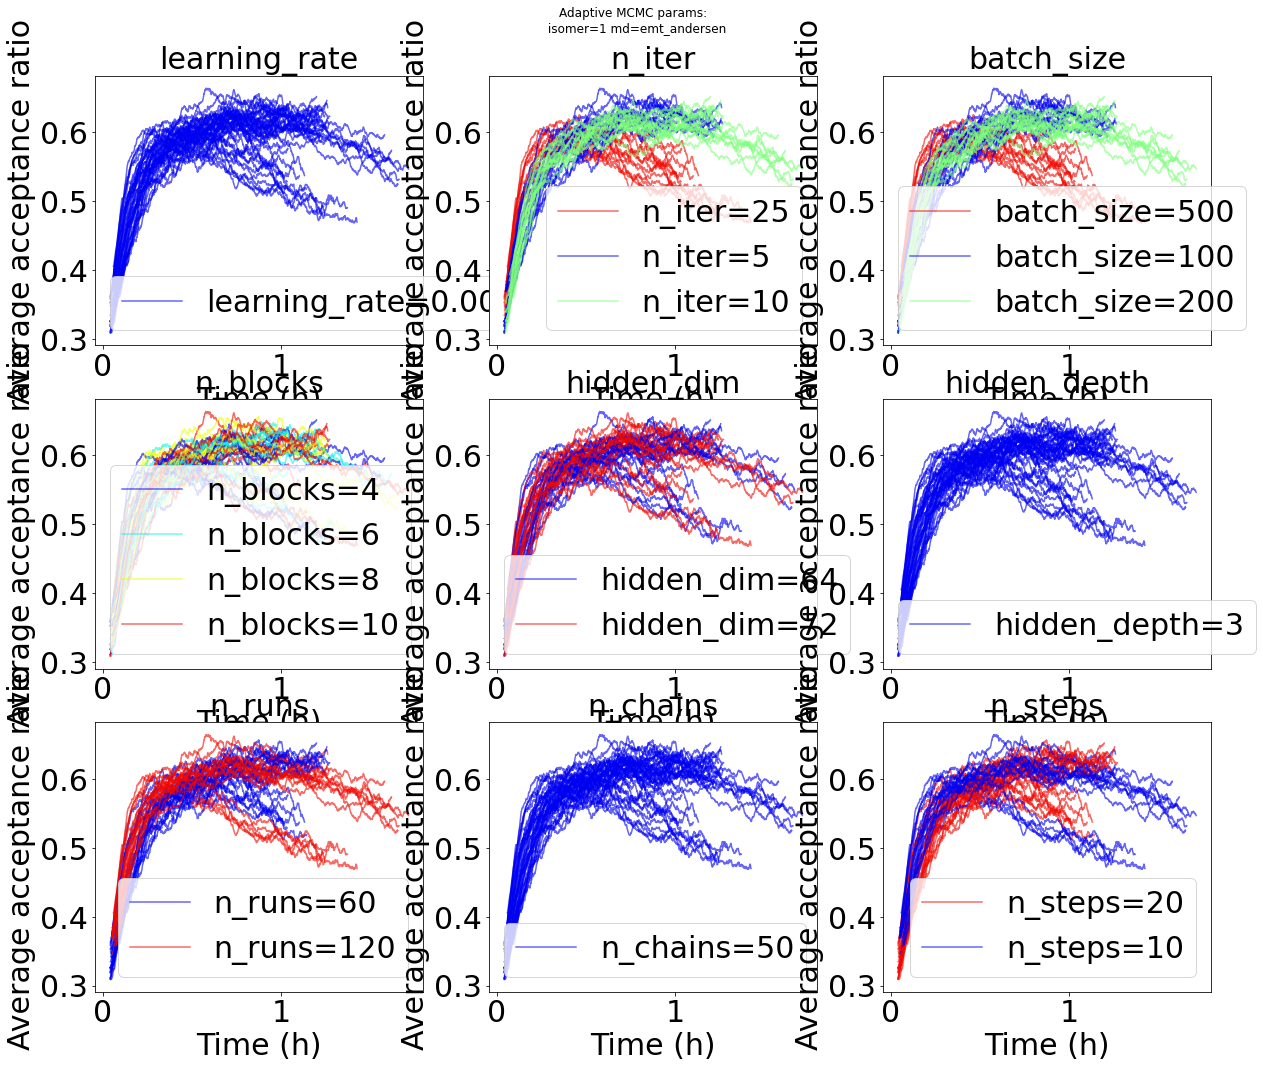

In [48]:
plot_hyperparams_search_with_ratios(emt_grid_search, "all_accs", "Average acceptance ratio", window=100, upper_bound=0.6);

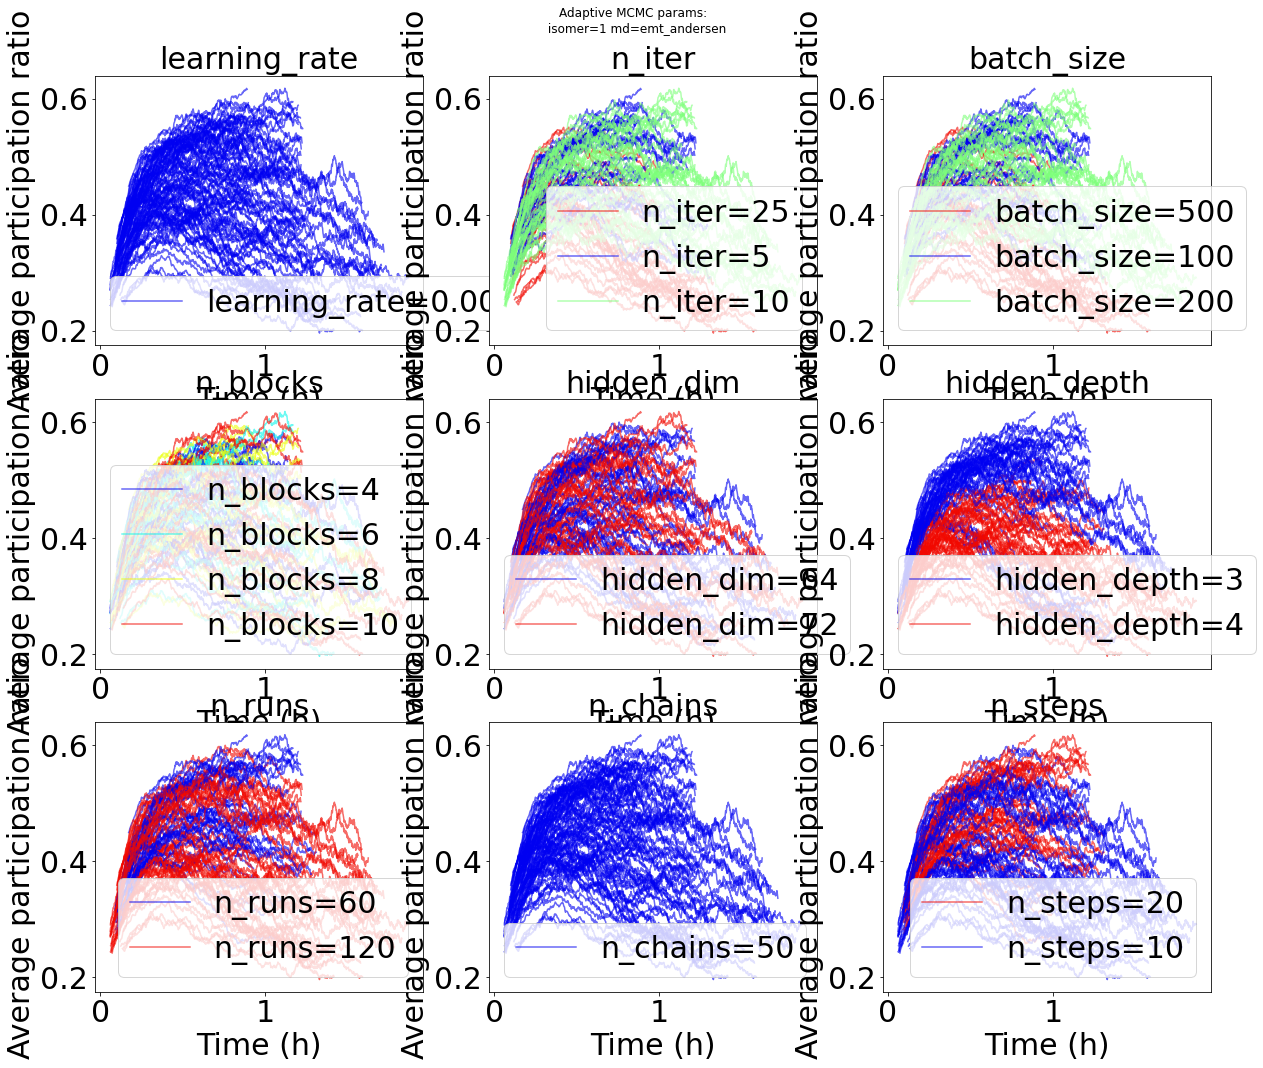

In [49]:
plot_hyperparams_search_with_ratios(emt_grid_search, "all_part_ratios", "Average participation ratio", window=100, upper_bound=0.0);

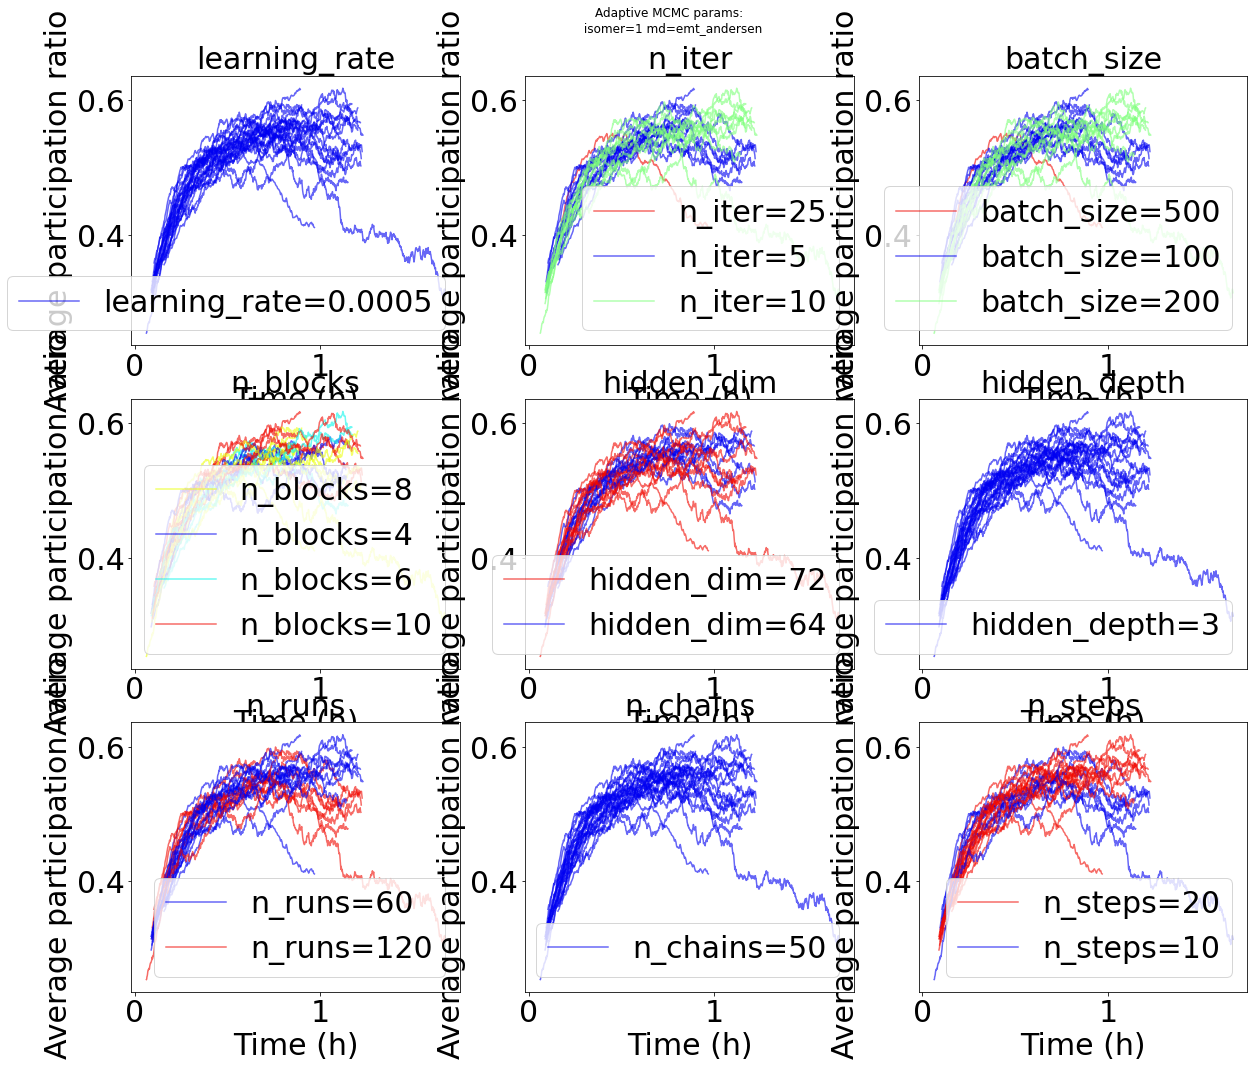

In [50]:
plot_hyperparams_search_with_ratios(emt_grid_search, "all_part_ratios", "Average participation ratio", window=100, upper_bound=0.55);

## DFT acceptance rate

In [51]:
ids = [2507255, 2512862]
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2/"

In [52]:
dft_is0 = [load_simulation_info(id_, 0, 0, False, path) for id_ in ids]
dft_is1 = [load_simulation_info(id_, 1, 1, False, path) for id_ in ids]

In [53]:
md = np.unique([dft_is[1]["folder_path"] for dft_is in dft_is0+dft_is1])


hyperparams = ['learning_rate', 'n_iter', 'batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'n_runs', 'n_chains', 'n_steps']
hyperparams_values = [[] for i in range(len(hyperparams))]

for i in range(len(hyperparams)):
    for dft_is in dft_is0+dft_is1:
        args = dft_is[1]
        hyperparams_values[i].append(args[hyperparams[i]])
            
hyperparams_values = [np.unique(hyperparams_values[i]) for i in range(len(hyperparams))]

In [54]:
hyperparams = dict(zip(hyperparams, hyperparams_values))
hyperparams

{'learning_rate': array([0.0005]),
 'n_iter': array([25]),
 'batch_size': array([500]),
 'n_blocks': array([4, 6]),
 'hidden_dim': array([64]),
 'hidden_depth': array([3]),
 'n_runs': array([30]),
 'n_chains': array([50]),
 'n_steps': array([20])}

Text(0.5, 0.98, 'Adaptive MCMC params: \n md=andersen nruns=30 nchains=50 nsteps=20 \n lr=0.0005 bs=500 epochs=25 hdm=64 hdp=3')

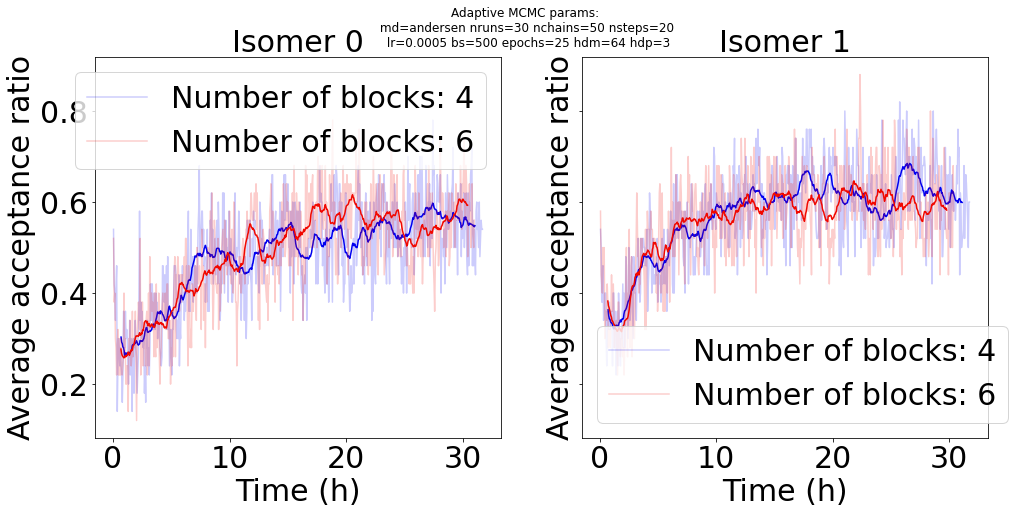

In [55]:
window = 25

fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

c = cm.jet(np.linspace(0.1, 0.9, len(dft_is0)))

for i, dft_isomer in enumerate([dft_is0, dft_is1]):
    
    for j, dft_is in enumerate(dft_isomer):
        
        x = dft_is[0][:, 1]/(3600)
        y = dft_is[0][:, 0]
    
        x_avg = avg_windows(x, window, axis=1)
        y_avg = avg_windows(y, window, axis=1)
            
        axs[i].plot(x, y, alpha=0.2, c=c[j], label="Number of blocks: {:d}".format(dft_is[1]['n_blocks']))
        axs[i].plot(x_avg, y_avg, c=c[j])
        axs[i].set_title('Isomer {:d}'.format(i))
        
        axs[i].set_xlabel("Time (h)")
        axs[i].set_ylabel("Average acceptance ratio")
        
        #axs[i].set_ylim(0, 1)
        axs[i].legend()
        
fig.suptitle("Adaptive MCMC params: \n md={} nruns={} nchains={} nsteps={} \n lr={} bs={} epochs={} hdm={} hdp={}".format(
                                                                                            md[0],
                                                                                            hyperparams["n_runs"][0],
                                                                                            hyperparams["n_chains"][0],
                                                                                            hyperparams["n_steps"][0],
                                                                                            hyperparams["learning_rate"][0],
                                                                                            hyperparams["batch_size"][0],
                                                                                            hyperparams["n_iter"][0],
                                                                                            hyperparams["hidden_dim"][0],
                                                                                            hyperparams["hidden_depth"][0],   
                                                                                            ), )       

## Multimodal sampling

In [180]:
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data

In [181]:
# Plot percentage of is0 and is1 during the chain evolution, check convergence! Plot also with MCMC steps two compare

In [182]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_1/results_multimodal_sampling_mixture_25263710/"
mh = load_pickle_file("mixture_mcmc_dic_25263710.pkl", path)

In [183]:
# Restart the chains
path_restarted = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_1/results_multimodal_sampling_mixture_25263710/results_multimodal_sampling_mixture_2533889/"
mh_restarted = load_pickle_file("mixture_mcmc_dic_2533889.pkl", path_restarted)

In [184]:
path_restarted_2 = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_1/results_multimodal_sampling_mixture_25263710/results_multimodal_sampling_mixture_2533889/results_multimodal_sampling_mixture_2547826/"
mh_restarted_2 = load_pickle_file("mixture_mcmc_dic_2547826.pkl", path_restarted_2)

In [185]:
path_restarted_3 = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_1/results_multimodal_sampling_mixture_25263710/results_multimodal_sampling_mixture_2533889/results_multimodal_sampling_mixture_2547826/results_multimodal_sampling_mixture_2549461/"
mh_restarted_3 = load_pickle_file("mixture_mcmc_dic_2549461.pkl", path_restarted_3)

In [186]:
path_restarted_4 = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_1/results_multimodal_sampling_mixture_25263710/results_multimodal_sampling_mixture_2533889/results_multimodal_sampling_mixture_2547826/results_multimodal_sampling_mixture_2549461/results_multimodal_sampling_mixture_2550753/"
mh_restarted_4 = load_pickle_file("mixture_mcmc_dic_2550753.pkl", path_restarted_4)

tensor([250])
tensor([250, 100])
tensor([250, 100, 200])
tensor([250, 100, 200, 300])
tensor([250, 100, 200, 300, 300])


Text(0.5, 0, 'MCMC steps')

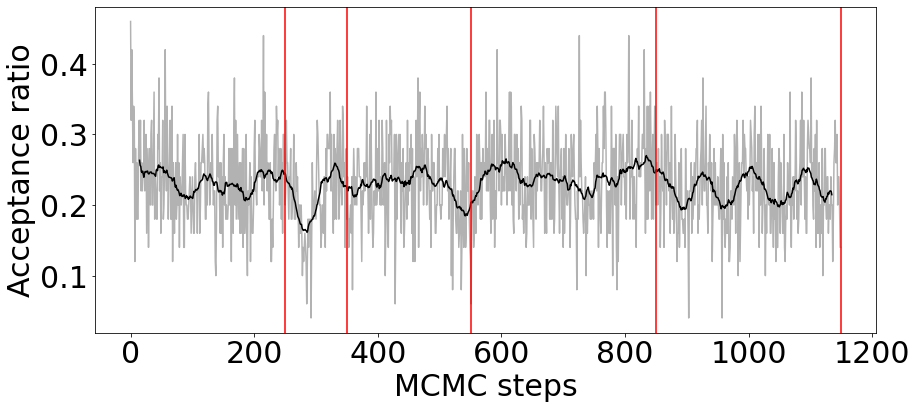

In [204]:
accs = torch.cat((mh['accs'].mean(dim=1), mh_restarted['accs'].mean(dim=1), mh_restarted_2['accs'].mean(dim=1), mh_restarted_3['accs'].mean(dim=1), mh_restarted_4['accs'].mean(dim=1)))
fig, ax = plt.subplots(figsize=(14, 6))
set_plot_sequential_data(accs, window_size=30, ax=ax)
number_steps_per_restarting = torch.tensor([mh['accs'].mean(dim=1).shape[0], 
 mh_restarted['accs'].mean(dim=1).shape[0], 
 mh_restarted_2['accs'].mean(dim=1).shape[0], 
 mh_restarted_3['accs'].mean(dim=1).shape[0], 
 mh_restarted_4['accs'].mean(dim=1).shape[0]])
for i in range(1, len(number_steps_per_restarting)+1):
    print(number_steps_per_restarting[:i]),
    ax.axvline(number_steps_per_restarting[:i].sum(), color='r')
ax.set_ylabel("Acceptance ratio")
ax.set_xlabel("MCMC steps")

In [205]:
isomers = torch.cat((mh["isomers"], mh_restarted["isomers"], mh_restarted_2["isomers"], mh_restarted_3["isomers"], mh_restarted_4["isomers"]))

tensor(99.2748)

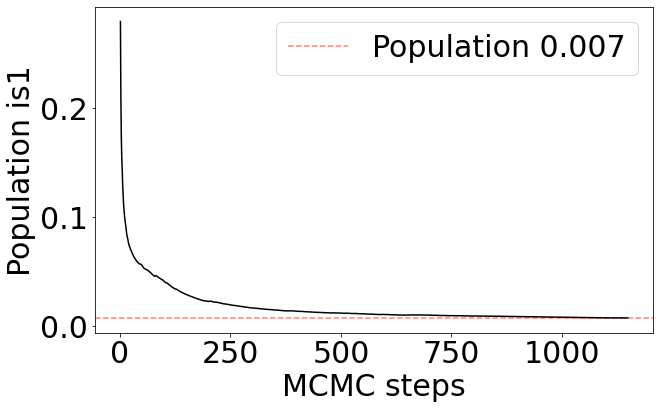

In [206]:
population_is1 = [isomers[:i].mean().item() for i in range(isomers.shape[0])]

plt.figure(figsize=(10, 6))
plt.axhline(isomers.mean().detach(), color='r', linestyle='--', alpha=0.5, label="Population {:.3f}".format(isomers.mean().detach()))
plt.plot(population_is1, 'k-')
plt.xlabel("MCMC steps")
plt.ylabel("Population is1")
plt.legend()
(1-isomers.mean().detach())*100

# Updating weights

In [165]:
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data

from matplotlib.pyplot import cm
size=30
import matplotlib.pylab as pylab
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}
pylab.rcParams.update(params)

path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_2/results_multimodal_sampling_mixture_25346510/"
mh = load_pickle_file("mixture_mcmc_dic_25346510.pkl", path)

Text(0.5, 0, 'MCMC steps')

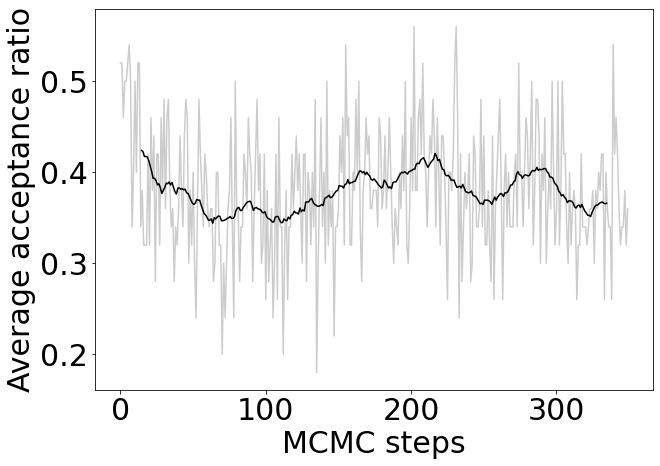

In [166]:
accs = mh['accs'].mean(dim=1)
fig, ax = plt.subplots(figsize=(10, 7))
set_plot_sequential_data(accs, window_size=30, ax=ax, alpha=0.2)
ax.set_ylabel("Average acceptance ratio")
ax.set_xlabel("MCMC steps")

tensor(99.5200)

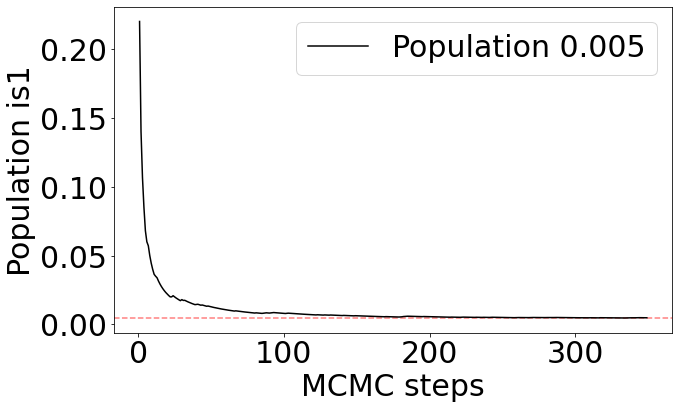

In [167]:
isomers = mh["isomers"]
population_is1 = [isomers[:i].mean().item() for i in range(isomers.shape[0])]

plt.figure(figsize=(10, 6))
plt.axhline(isomers.mean().detach(), color='r', linestyle='--', alpha=0.5)
plt.plot(population_is1, 'k-', label="Population {:.3f}".format(isomers.mean().detach()))
plt.xlabel("MCMC steps")
plt.ylabel("Population is1")
plt.legend()
(1-isomers.mean().detach())*100

tensor(99.5200)

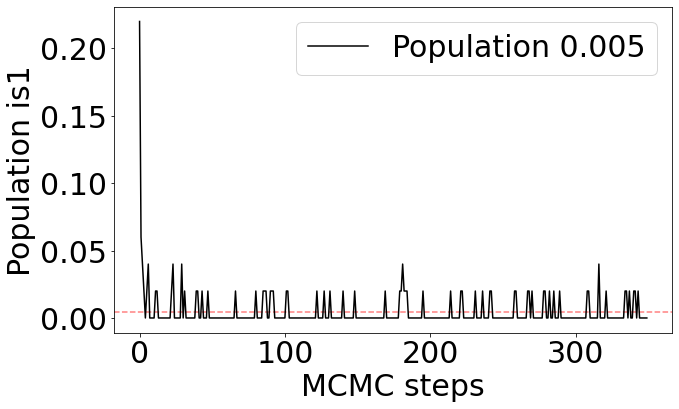

In [173]:
# How it looks per step!

isomers = mh["isomers"]
population_is1 = [isomers[i].mean().item() for i in range(isomers.shape[0])]

plt.figure(figsize=(10, 6))
plt.axhline(isomers.mean().detach(), color='r', linestyle='--', alpha=0.5)
plt.plot(population_is1, 'k-', label="Population {:.3f}".format(isomers.mean().detach()))
plt.xlabel("MCMC steps")
plt.ylabel("Population is1")
plt.legend()
(1-isomers.mean().detach())*100

In [168]:
us = mh['us']
xs = mh['xs']
isomers = mh['isomers']
nlls = torch.zeros(us.shape)

flows = [load_pickle_file("flow_model_is{:d}.pkl".format(i), path="/mnt/home/amolina/ceph/ml-dft/database/andersen/models/") for i in range(2)]

In [169]:
for i in range(us.shape[0]):

    xs_is0 = xs[i][~isomers[i].bool()]
    xs_is1 = xs[i][isomers[i].bool()]
    
    if xs_is1.nelement() == 0:
        
        nlls[i][~isomers[i].bool()] = flows[0].nll(xs_is0)
        
    else:
        nlls[i][~isomers[i].bool()] = flows[0].nll(xs_is0)
        nlls[i][isomers[i].bool()] = flows[1].nll(xs_is1)

Text(0.5, 0, 'energy [e.V]')

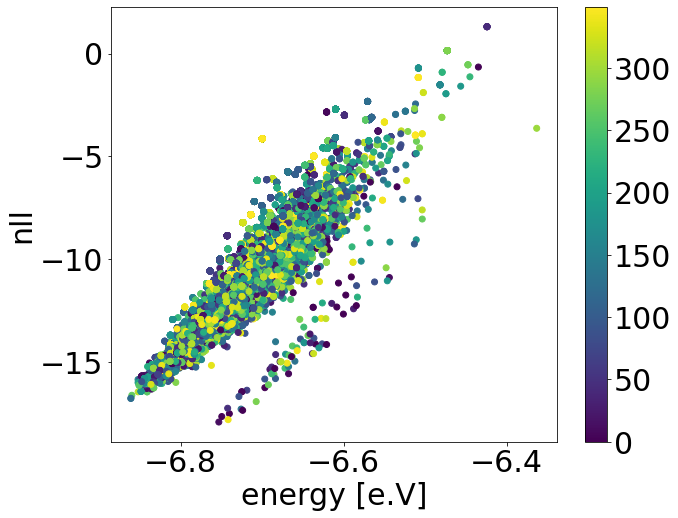

In [174]:
us = us.detach()
nlls = nlls.detach()

plt.figure(figsize=(10, 8))
for chain in range(0, 50, 1):
    plt.scatter(us[:, chain], nlls[:, chain], c=range(0, us.shape[0]), )
plt.colorbar()
plt.ylabel('nll')
plt.xlabel('energy [e.V]')

In [67]:
import seaborn as sns

In [68]:
us = mh["us"]
isomers = mh["isomers"]

In [69]:
us_is0 = us.flatten().detach()[~isomers.flatten().detach().bool()]
us_is1 = us.flatten().detach()[isomers.flatten().detach().bool()]

energies = {'mcmc': us.flatten().detach(),
            'is0': us_is0,
            'is1': us_is1,
           }

Text(0.5, 0, 'Potential energy [e.V]')

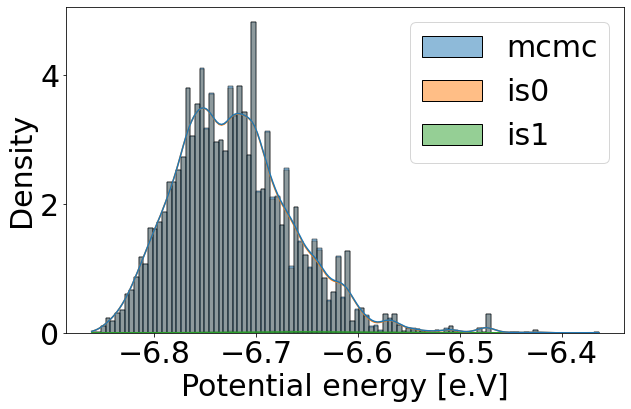

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(energies, stat='density', kde=True, ax=ax, common_norm=True, fill=True, alpha=0.5);
ax.set_xlabel("Potential energy [e.V]")

In [71]:
import torch
from flonacomldft.internal_coordinates import Coordinates_mapping

In [72]:
coord_mapping = Coordinates_mapping()

In [73]:
xs = mh["xs"][:50]
isomers = mh["isomers"][:50]

In [74]:
cvs = [] 

for xs_step, isomers_step in zip(xs, isomers):
    
    cv_step = []
    
    for x_chain, isomer_chain in zip(xs_step, isomers_step):
        
        cv_chain = coord_mapping.get_collective_variables_from_real_centered(x_chain, isomer=isomer_chain.item())
        cv_step.append(cv_chain)
          
    cvs.append(torch.stack(cv_step).detach())

In [75]:
cvs = torch.stack(cvs)

In [76]:
cvs_flatten = cvs.clone().reshape(cvs.shape[0]*cvs.shape[1], cvs.shape[2])
us_flatten = us.clone()[:50].flatten().reshape(-1, 1)

data = torch.cat((cvs_flatten, us_flatten), dim=1).detach()

df = pd.DataFrame(data, columns=['CV1', 'CV2', 'U'])

In [77]:
from flonacomldft.utils.plots import plot_energy_surface

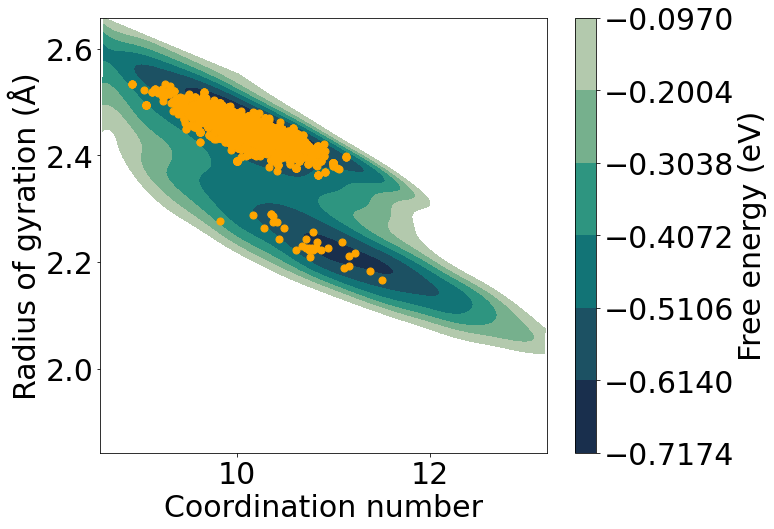

In [78]:
init = 0
end = -1

#fig, ax = plt.subplots(1, 1, figsize=(12, 8))
plot_energy_surface()#fig=fig, ax=ax)
plt.scatter(df['CV1'][init:end], df['CV2'][init:end], c='orange', s=50)#c=df['U'][init:end], cmap='bwr')
#plt.colorbar(label='Potential Energy [e.V]')

No figure provided. Cannot add colorbar.


(2.0, 2.6)

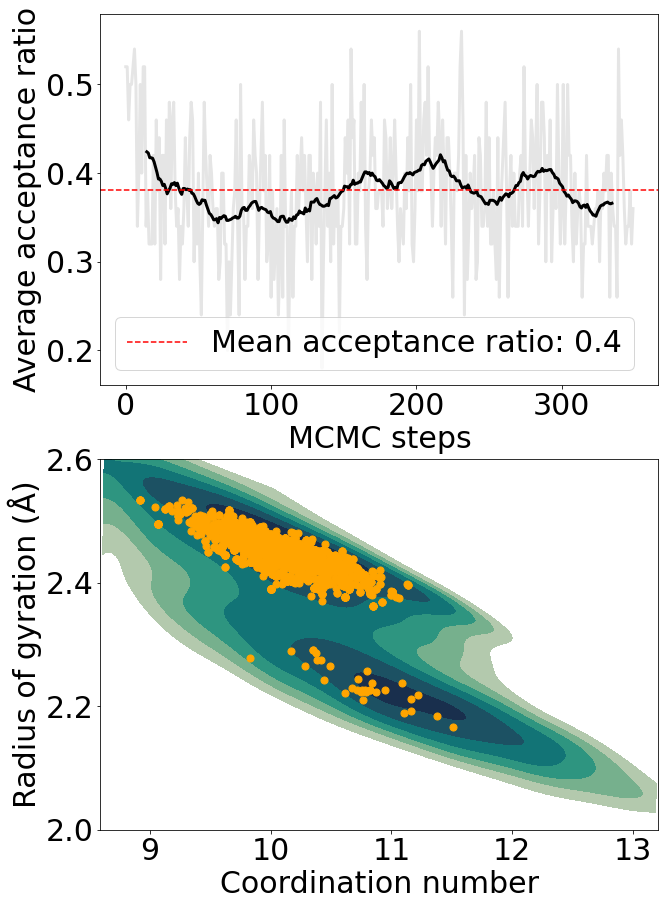

In [79]:
accs = mh['accs'].mean(dim=1)
fig, ax = plt.subplots(2, 1, figsize=(10, 15))
set_plot_sequential_data(accs, window_size=30, ax=ax[0], alpha=0.1, linewidth=3)
ax[0].axhline(accs.mean(), label="Mean acceptance ratio: {:.1f}".format(accs.mean()), color='r', linestyle='--',)
ax[0].set_ylabel("Average acceptance ratio")
ax[0].set_xlabel("MCMC steps")
ax[0].legend()

plot_energy_surface(ax=ax[1])#fig=fig, ax=ax)
ax[1].scatter(df['CV1'][init:end], df['CV2'][init:end], c='orange', s=50)
ax[1].set_ylim(2.0, 2.6)

In [81]:
#sns.jointplot(df, x="CV1", y="CV2", hue="U")

#g = sns.JointGrid(
#    data=df, x="CV1", y="CV2",# hue="U"
#)
#g.plot_joint(sns.kdeplot)
#g.plot_marginals(sns.histplot, element="step", fill=True, stat='density', common_bins=False, common_norm=False)